# **First Try of the training mentioned in 'Methodology'**

Based on **BLIP2**: https://huggingface.co/docs/transformers/en/model_doc/blip-2


## **Methodology**
- Vision Encoding: BLIP-2 ViT-L (Li et al., 2023) Pre-trained on 129M image-text pairs 1.2B parameters, outputs 1408-dimensional visual features
- Text Generation: mT5-base (Xue et al., 2021) Pre-trained on multilingual C4 (mC4) covering 101 languages 580M parameters, 768-dimensional hidden states.
- Connection: Q-Former-style projection - Learnable linear mapping from BLIP-2 space (1408-dim) to mT5 space (768-dim).


We train the **Connection**

**Remarks**

This is runned on Google Colab, and under an environment where the model and requirements are not downloaded

In [21]:
!ls /content

coco_5	drive  sample_data


In [6]:
!rm -rf /content/drive

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
!ls "/content/drive/MyDrive/MLP Project/MLP Group"

 Dataset  'LMCAP Test.ipynb'  'MBlip Test.ipynb'  'MLP Test.ipynb'
 lmcap	   mblip_model	      'MLP Test2.ipynb'


In [ ]:
!mkdir -p "/content/drive/MyDrive/MLP Project/MLP Group/lmcap"

**Check GPU is chosen**

In [24]:
import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

True NVIDIA A100-SXM4-80GB


## Testing --- **CONCAP/LMCAP/mBlip**

### **CONCAP**

Not available

### **LMCAP**

https://github.com/RitaRamo/lmcap


In [1]:
!git clone https://github.com/RitaRamo/lmcap.git \
"/content/drive/MyDrive/MLP Project/MLP Group/lmcap"

Cloning into '/content/drive/MyDrive/MLP Project/MLP Group/lmcap'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 62 (delta 14), reused 45 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 28.69 KiB | 14.34 MiB/s, done.
Resolving deltas: 100% (14/14), done.


In [25]:
!ls "/content/drive/MyDrive/MLP Project/MLP Group/lmcap"

data  datastore  experiments  README.md  requirements.txt  src


**Add Dependencies**

In [26]:
%cd "/content/drive/MyDrive/MLP Project/MLP Group/lmcap"

/content/drive/MyDrive/MLP Project/MLP Group/lmcap


In [ ]:
!pip install -r requirements.txt
!pip install faiss-cpu huggingface_hub

/content/drive/MyDrive/MLP Project/MLP Group/lmcap
Processing /opt/conda/conda-bld/absl-py_1639803114343/work (from -r requirements.txt (line 1))
ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: '/opt/conda/conda-bld/absl-py_1639803114343/work'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 56.5 MB/s eta 0:00:00


Check features are here

In [27]:
!ls

data  datastore  experiments  README.md  requirements.txt  src


**Get some data**

In [28]:
!ls data

caps_retrieved	caps_support  categories  coco2014  features  __init__.py


In [ ]:
!wget -q -O features.zip https://huggingface.co/RitaParadaRamos/lmcap/resolve/main/features.zip
!wget -q -O caps_retrieved.zip https://huggingface.co/RitaParadaRamos/lmcap/resolve/main/caps_retrieved.zip
!wget -q -O caps_support.zip https://huggingface.co/RitaParadaRamos/lmcap/resolve/main/caps_support.zip
!wget -q -O categories.zip https://huggingface.co/RitaParadaRamos/lmcap/resolve/main/categories.zip

In [ ]:
!unzip -o features.zip
!unzip -o caps_retrieved.zip
!unzip -o caps_support.zip
!unzip -o categories.zip

Archive:  features.zip
  inflating: features/extract_xm3600.sh  
  inflating: features/xm3600_clip_multilingual_large.hdf5  
  inflating: features/coco2014_clip_multilingual_large.hdf5  
  inflating: features/extract_coco.sh  
Archive:  caps_retrieved.zip
  inflating: caps_retrieved/xm3600/distances_setup_coco2014.json  
  inflating: caps_retrieved/xm3600/__init__.py  
  inflating: caps_retrieved/xm3600/nn_setup_coco2014.json  
  inflating: caps_retrieved/coco2014/distances_setup_coco2014.json  
  inflating: caps_retrieved/coco2014/__init__.py  
  inflating: caps_retrieved/coco2014/nn_setup_coco2014.json  
Archive:  caps_support.zip
  inflating: caps_support/coco2014/__init__.py  
  inflating: caps_support/coco2014/retrieved_caps.json  
  inflating: caps_support/coco2014/reference_caps.json  
Archive:  categories.zip
  inflating: categories/categories_places365.txt  
  inflating: categories/dictionary_and_semantic_hierarchy.txt  
  inflating: categories/get_categories_xm3600.sh  
  inf

**Check Current Version and Requirements**

In [29]:
import transformers, torch, tokenizers, sys
print("python:", sys.version)
print("transformers:", transformers.__version__)
print("torch:", torch.__version__)
print("tokenizers:", tokenizers.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
transformers: 4.46.3
torch: 2.10.0+cu128
tokenizers: 0.20.3
cuda available: True
gpu: NVIDIA A100-SXM4-80GB


In [30]:
!sed -n '1,120p' requirements.txt

absl-py @ file:///opt/conda/conda-bld/absl-py_1639803114343/work
accelerate==0.21.0
aiofiles==23.1.0
aiohttp @ file:///tmp/build/80754af9/aiohttp_1646806365504/work
aiosignal @ file:///tmp/build/80754af9/aiosignal_1637843061372/work
anyio==3.7.0
appdirs==1.4.4
aria2p==0.11.2
asciimatics==1.14.0
astor==0.8.1
astunparse==1.6.3
async-timeout @ file:///tmp/build/80754af9/async-timeout_1637851218186/work
attrs @ file:///opt/conda/conda-bld/attrs_1642510447205/work
blinker==1.4
blis==0.7.10
brotlipy==0.7.0
cached-property==1.5.2
cachetools @ file:///tmp/build/80754af9/cachetools_1619597386817/work
catalogue==1.0.2
certifi==2022.5.18.1
cffi @ file:///opt/conda/conda-bld/cffi_1642701102775/work
charset-normalizer @ file:///tmp/build/80754af9/charset-normalizer_1630003229654/work
click @ file:///tmp/build/80754af9/click_1646056590078/work
clip @ git+https://github.com/openai/CLIP.git@a1d071733d7111c9c014f024669f959182114e33
conda==4.13.0
conda-package-handling @ file:///tmp/build/80754af9/conda

### **Full Downgrade**

In [1]:
!pip uninstall -y transformers tokenizers
!pip install "transformers==4.46.3"

Found existing installation: transformers 4.46.3
Uninstalling transformers-4.46.3:
  Successfully uninstalled transformers-4.46.3
Found existing installation: tokenizers 0.20.3
Uninstalling tokenizers-0.20.3:
  Successfully uninstalled tokenizers-0.20.3
  Using cached transformers-4.46.3-py3-none-any.whl.metadata (44 kB)
  Using cached tokenizers-0.20.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
Using cached transformers-4.46.3-py3-none-any.whl (10.0 MB)
Using cached tokenizers-0.20.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.0 MB)


In [13]:
# import json, os, h5py

# N = 5

# # 1) 读 retrieval 文件（有哪些 coco_id 有检索结果）
# retr_path = "data/caps_retrieved/coco2014/nn_setup_coco2014.json"
# retr = json.load(open(retr_path, "r"))

# # retr 的结构可能是 dict: { "100182": [...], ... }
# retr_ids = set(retr.keys())

# # 2) 读 features 里有哪些 id
# with h5py.File("data/features/coco2014_clip_multilingual_large.hdf5", "r") as f:
#     feat_ids = set(f.keys())

# # 3) 取交集：既有 features 又有 retrieval
# valid_ids = sorted([int(i) for i in (retr_ids & feat_ids)])
# print("retrieval ids:", len(retr_ids))
# print("feature ids:", len(feat_ids))
# print("valid ids:", len(valid_ids))
# print("first 5 valid:", valid_ids[:5])

# # 4) 写 split（LMCap 需要 val_images）
# os.makedirs("data/coco2014/datasets", exist_ok=True)
# split_path = "data/coco2014/datasets/dataset_splits.json"
# with open(split_path, "w") as fp:
#     json.dump({"val_images": valid_ids[:N]}, fp)

# print("Wrote split:", split_path, "N =", N)

retrieval ids: 10000
feature ids: 123287
valid ids: 10000
first 5 valid: [42, 139, 285, 359, 474]
Wrote split: data/coco2014/datasets/dataset_splits.json N = 5


In [31]:
import json, os, h5py

N = 5

# retrieval ids
retr = json.load(open("data/caps_retrieved/coco2014/nn_setup_coco2014.json", "r"))
retr_ids = set(retr.keys())

# feature ids
with h5py.File("data/features/coco2014_clip_multilingual_large.hdf5", "r") as f:
    feat_ids = set(f.keys())

# categories ids (must cover socratic)
cats_dir = "data/categories/coco2014"
img_type = json.load(open(os.path.join(cats_dir, "img_type.json"), "r"))
cat_ids = set(img_type.keys())

# find the pics that appears to all
valid_ids = sorted([int(i) for i in (retr_ids & feat_ids & cat_ids)])
print("retrieval ids:", len(retr_ids))
print("feature ids:", len(feat_ids))
print("category ids:", len(cat_ids))
print("valid ids (all 3):", len(valid_ids))
print("first 20 valid:", valid_ids[:20])

# split
os.makedirs("data/coco2014/datasets", exist_ok=True)
split_path = "data/coco2014/datasets/dataset_splits.json"
with open(split_path, "w") as fp:
    json.dump({"val_images": valid_ids[:N]}, fp)

print("Wrote split:", split_path, "N =", N, "val_images =", valid_ids[:N])

retrieval ids: 10000
feature ids: 123287
category ids: 123287
valid ids (all 3): 10000
first 20 valid: [42, 139, 285, 359, 474, 636, 661, 711, 810, 939, 974, 985, 1146, 1153, 1180, 1290, 1340, 1347, 1353, 1369]
Wrote split: data/coco2014/datasets/dataset_splits.json N = 5 val_images = [42, 139, 285, 359, 474]


In [32]:
import json, os
cats_dir = "data/categories/coco2014"
img_type = json.load(open(os.path.join(cats_dir, "img_type.json"), "r"))

print("has key '139' ?", "139" in img_type)
print("has key 139 ?", 139 in img_type)

# check keys
keys = list(img_type.keys())
print("example keys:", keys[:5])
print("key type:", type(keys[0]))

has key '139' ? True
has key 139 ? False
example keys: ['184613', '403013', '562150', '360772', '340559']
key type: <class 'str'>


### **Print Images**

42 -> OK http://images.cocodataset.org/val2014/COCO_val2014_000000000042.jpg
139 -> OK http://images.cocodataset.org/val2014/COCO_val2014_000000000139.jpg
285 -> OK http://images.cocodataset.org/val2014/COCO_val2014_000000000285.jpg
359 -> OK http://images.cocodataset.org/val2014/COCO_val2014_000000000359.jpg
474 -> OK http://images.cocodataset.org/val2014/COCO_val2014_000000000474.jpg


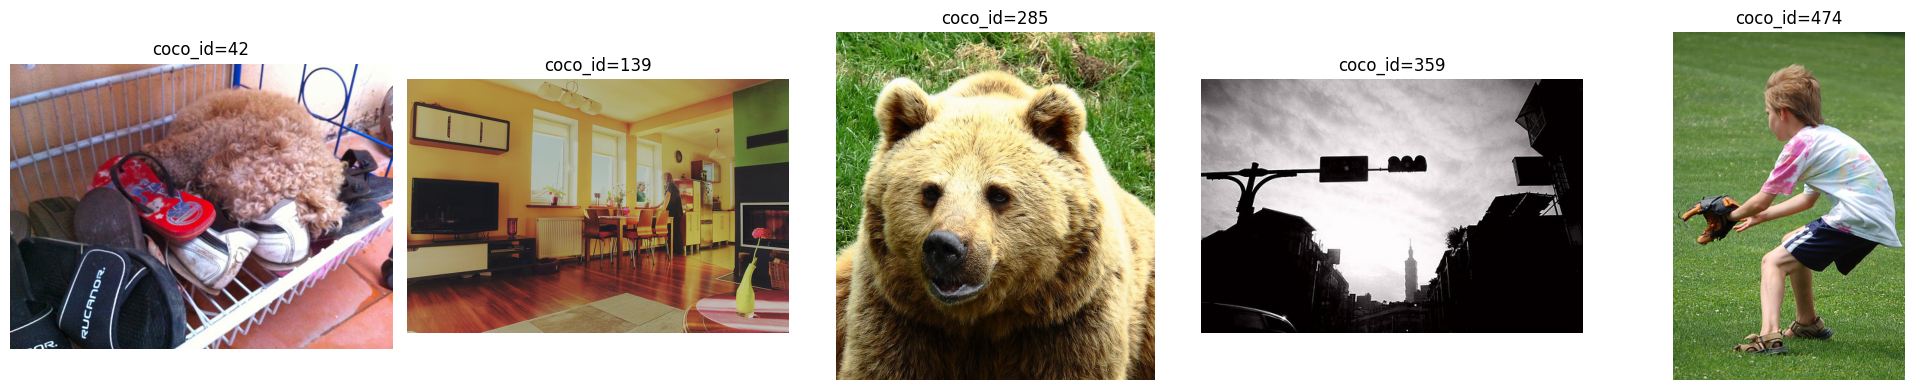

In [33]:
import os, requests
from PIL import Image
import matplotlib.pyplot as plt

ids = [42, 139, 285, 359, 474]
out_dir = "/content/coco_5"
os.makedirs(out_dir, exist_ok=True)

def try_download(coco_id: int):
    candidates = [
        f"http://images.cocodataset.org/val2014/COCO_val2014_{coco_id:012d}.jpg",
        f"http://images.cocodataset.org/train2014/COCO_train2014_{coco_id:012d}.jpg",
    ]
    for url in candidates:
        fn = os.path.join(out_dir, os.path.basename(url))
        r = requests.get(url, timeout=30)
        if r.status_code == 200 and r.headers.get("content-type","").startswith("image"):
            with open(fn, "wb") as f:
                f.write(r.content)
            return fn, url
    return None, None

paths = []
for coco_id in ids:
    fn, url = try_download(coco_id)
    print(coco_id, "->", ("OK " + url) if fn else "NOT FOUND")
    if fn:
        paths.append((coco_id, fn))

# show five pics
cols = min(5, len(paths))
rows = (len(paths) + cols - 1) // cols if cols else 1
plt.figure(figsize=(4*cols, 4*rows))
for i, (coco_id, fn) in enumerate(paths, start=1):
    img = Image.open(fn).convert("RGB")
    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.title(f"coco_id={coco_id}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### **Run the Model**

In [34]:
!python3 src/eval.py \
  --dataset coco2014 \
  --dataset_splits data/coco2014/datasets/dataset_splits.json \
  --retrieve_filename data/caps_retrieved/coco2014/nn_setup_coco2014.json \
  --support_reference_caps data/caps_support/coco2014/reference_caps.json \
  --support_retrieved_caps data/caps_support/coco2014/retrieved_caps.json \
  --output_path experiments/demo_paper_like \
  --split val \
  --template_type retrieval \
  --language en \
  --k 4 \
  --in_context --n_context 3 \
  --batch_size 1 \
  --beam_size 3 --eval_beam_size 3 \
  --min_caption_len 10 \
  --max_caption_len 30 \
  --xglm_type 2.9B

2026-03-06 18:31:10.917653: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-06 18:31:10.936315: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772821870.958715    8700 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772821870.966133    8700 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772821870.985122    8700 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [35]:
!find experiments/demo_paper_like -type f | sort

experiments/demo_paper_like/outputs/coco2014_retrieval_en_4_3_val.beam_3.json
experiments/demo_paper_like/outputs/coco2014_retrieval_en_4_3_val.beam_3.top_3.json


In [36]:
!ls -l --time-style=full-iso experiments/demo_paper_like/outputs

total 2
-rw------- 1 root root 388 2026-03-06 18:31:36.000000000 +0000 coco2014_retrieval_en_4_3_val.beam_3.json
-rw------- 1 root root 881 2026-03-06 18:31:36.000000000 +0000 coco2014_retrieval_en_4_3_val.beam_3.top_3.json


In [37]:
import json

fn1 = "experiments/demo_paper_like/outputs/coco2014_retrieval_en_4_3_val.beam_3.json"
fn2 = "experiments/demo_paper_like/outputs/coco2014_retrieval_en_4_3_val.beam_3.top_3.json"

for fn in [fn1, fn2]:
    print("\nFILE:", fn)
    data = json.load(open(fn, "r"))
    print("type:", type(data))
    if isinstance(data, dict):
        print("num keys:", len(data))
        for k in list(data.keys())[:5]:
            print(k, "->", data[k])
    elif isinstance(data, list):
        print("num items:", len(data))
        for x in data[:5]:
            print(x)


FILE: experiments/demo_paper_like/outputs/coco2014_retrieval_en_4_3_val.beam_3.json
type: <class 'list'>
num items: 5
{'image_id': 285, 'caption': 'this is a close up picture of a big brown bear'}
{'image_id': 139, 'caption': 'A woman walking around her living room'}
{'image_id': 359, 'caption': 'A black and white photograph of traffic lights, car and buildings'}
{'image_id': 42, 'caption': 'A dog sleeping in a pile of shoes'}
{'image_id': 474, 'caption': 'A boy catches a baseball in his glove'}

FILE: experiments/demo_paper_like/outputs/coco2014_retrieval_en_4_3_val.beam_3.top_3.json
type: <class 'list'>
num items: 5
{'image_id': 285, 'captions': ['this is a close up picture of a big brown bear', 'this is a close up picture of a very large bear', 'this is a close up picture of a very big bear']}
{'image_id': 139, 'captions': ['A woman walking around her living room', 'A woman walking around her living room area', 'A woman sitting in the living room with a laptop']}
{'image_id': 359, 

### **Clear all output**

In [38]:
!pip install nbconvert
!jupyter nbconvert --ClearOutputPreprocessor.enabled=True --inplace LMCAP_Test.ipynb

[NbConvertApp] WARNING | pattern 'LMCAP_Test.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    